In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("datasets/Codelab Module 6.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Perform EDA
display(df.info())
display(df.describe())
display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


None

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

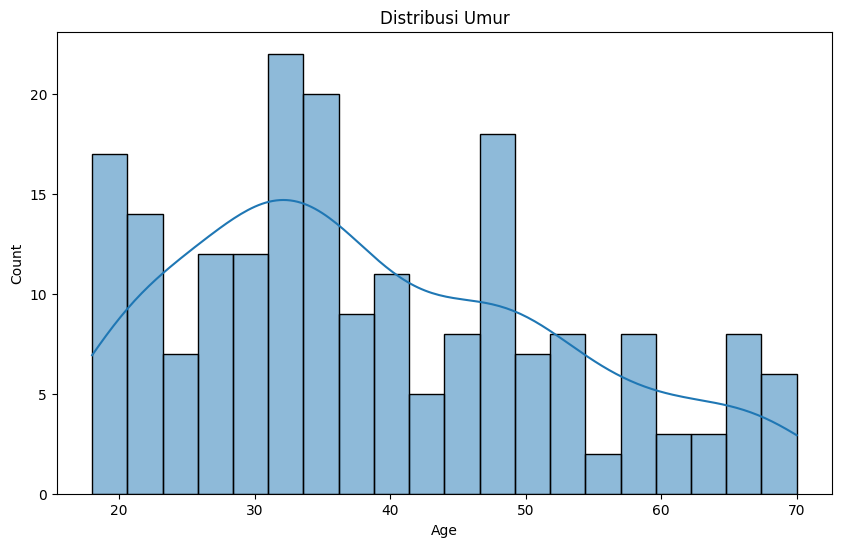

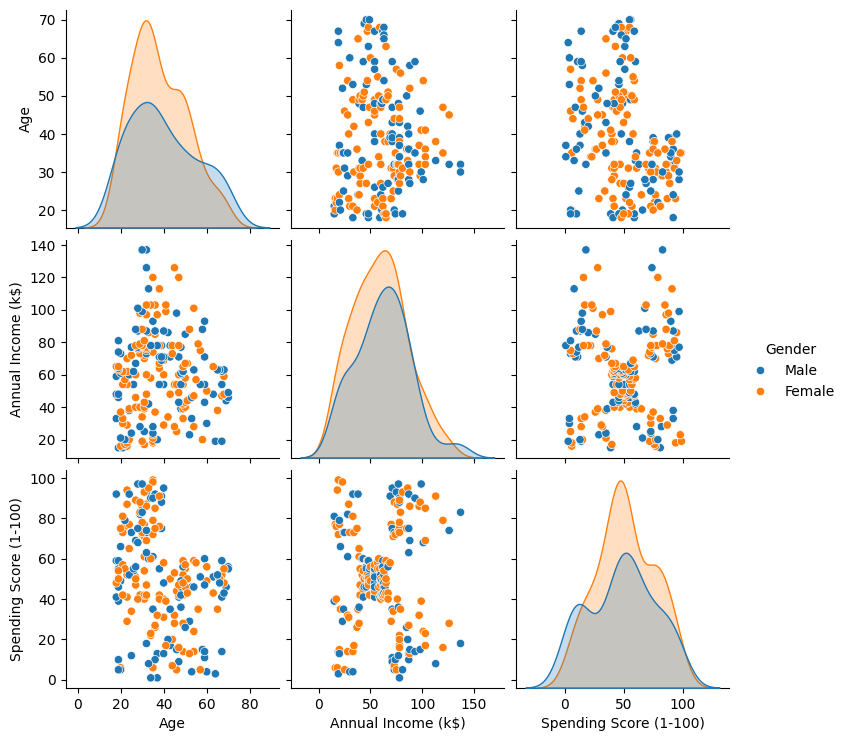

In [6]:
# Create data visualization
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', kde=True, bins=20)
plt.title('Distribusi Umur')
plt.show()

sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.show()

In [7]:
df_encoded = pd.get_dummies(df, columns=["Gender"], drop_first=True)
df_encoded.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


In [8]:
# Normalisasi Data: Usia, Pendapatan Tahunan, dan Skor Pengeluaran
scaler = MinMaxScaler() 
df_encoded[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = scaler.fit_transform(df_encoded[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
df_encoded.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,0.019231,0.000000,0.387755,True
1,2,0.057692,0.000000,0.816327,True
2,3,0.038462,0.008197,0.051020,False
3,4,0.096154,0.008197,0.775510,False
4,5,0.250000,0.016393,0.397959,False


In [9]:
# Gunakan metode Elbow untuk menentukan jumlah kluster yang ideal 
wcss = [] 
features = ['Annual Income (k$)', 'Spending Score (1-100)']
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) 
    kmeans.fit(df_encoded[features]) 
    wcss.append(kmeans.inertia_)

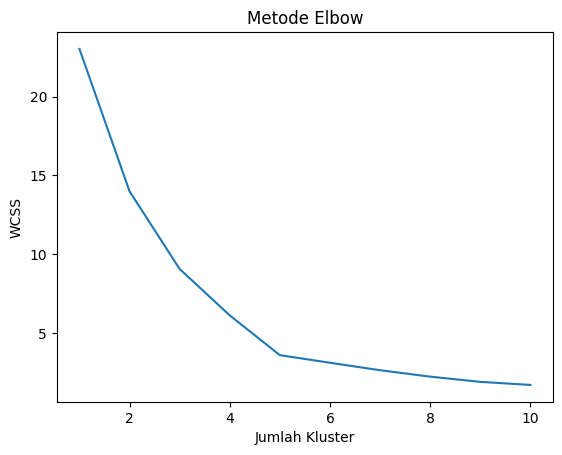

In [10]:
plt.plot(range(1, 11), wcss) 
plt.title('Metode Elbow') 
plt.xlabel('Jumlah Kluster') 
plt.ylabel('WCSS') 
plt.show()

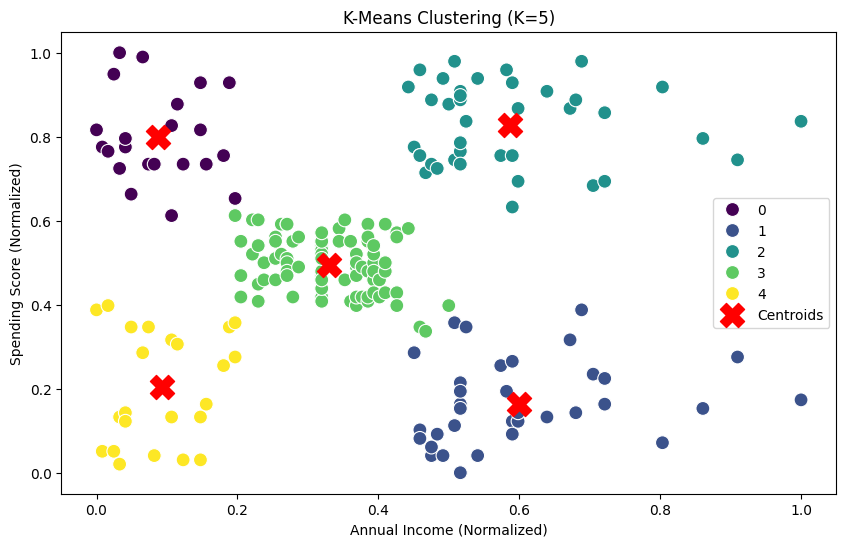

In [11]:
# Lanjutkan proses clustering
# Berdasarkan metode elbow, kita memilih 5 kluster
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_encoded[features])
df_encoded['Cluster'] = df['Cluster']

# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_encoded, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette='viridis', 
    s=100
)

# Plot titik pusat (centroids)
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=300, 
    c='red', 
    marker='X', 
    label='Centroids'
)
plt.title('K-Means Clustering (K=5)')
plt.xlabel('Annual Income (Normalized)')
plt.ylabel('Spending Score (Normalized)')
plt.legend()
plt.show()

Cluster Interpretation (10 Point) 
 
After determining the number of clusters, perform an analysis to understand the characteristics 
of each cluster

**Interpretasi Pelanggan (5 Kluster):**

1. **Kluster 0 (Pendapatan Rendah, Pengeluaran Rendah):** Pelanggan yang memiliki pendapatan tahunan rendah dan juga skor pengeluaran yang rendah. Segmen ini mungkin lebih hemat.
2. **Kluster 1 (Pendapatan Tinggi, Pengeluaran Tinggi):** Pelanggan dengan pendapatan tinggi dan skor pengeluaran tinggi. Target utama untuk promosi barang mewah atau premium.
3. **Kluster 2 (Pendapatan Sedang, Pengeluaran Sedang):** Mayoritas konsumen berada di kluster ini, mewakili rata-rata populasi dengan keseimbangan antara pendapatan dan pengeluaran.
4. **Kluster 3 (Pendapatan Tinggi, Pengeluaran Rendah):** Pelanggan berpenghasilan tinggi namun berhemat dalam berbelanja. Berpotensi ditarik dengan penawaran nilai tambah tinggi atau program loyalitas.
5. **Kluster 4 (Pendapatan Rendah, Pengeluaran Tinggi):** Pelanggan secara proporsional menghabiskan banyak uang meskipun pendapatan mereka rendah. Ini mungkin orang yang suka berbelanja impulsif atau menggunakan fitur kredit/cicilan.